#### ライブラリのimport

In [14]:
import pandas as pd
from google.cloud import bigquery
from google.cloud import storage
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import shap
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import matplotlib

#### データ取得

In [2]:
# BigQueryクライアントを作成する
client = bigquery.Client()

# 取得するデータの範囲を指定する
years = [2023, 2024, 2025]
place_ids = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10"]

# クエリを作成する
query = ""
for year in years:
    for place_id in place_ids:
        if year != years[0] or place_id != "01":
            query += " UNION ALL "
        query += f"""
        SELECT *
        FROM `keiba-ai-487108.datalake.race_result_{year}_{place_id}`
        """

# クエリを実行してデータを取得する
df = client.query(query).to_dataframe()

/Users/naozumi/Desktop/WorkSpace/keiba_ai_app/app/keiba_science/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


#### 前処理

In [3]:
# 馬名
if '馬' in df.columns:
    le_horse = LabelEncoder()
    df['馬名カテゴリ'] = le_horse.fit_transform(df['馬'])

# 騎手
if '騎手' in df.columns:
    le_jockey = LabelEncoder()
    df['騎手カテゴリ'] = le_jockey.fit_transform(df['騎手'])

In [4]:
# 単勝ラベル（1着予測用）を作成
df['単勝ラベル'] = (df['着順'] == "1").astype(int)

In [25]:
# 馬ごとの連対率を計算
def calc_ren_tai_rate(df, group_col):
    grouped = df.groupby(group_col)
    total = grouped.size()
    win = grouped.apply(lambda x: (x['着順'] == "1").sum())
    place2 = grouped.apply(lambda x: (x['着順'] == "2").sum())
    rentai = (win + place2) / total
    result = pd.DataFrame({
        f'{group_col}_出走数': total,
        f'{group_col}_勝利数': win,
        f'{group_col}_2着数': place2,
        f'{group_col}_連対率': rentai
    })
    return result.reset_index()

# 馬ごと
horse_rentai_df = calc_ren_tai_rate(df, '馬')
horse_rentai_df = horse_rentai_df.sort_values(f'馬_連対率', ascending=False)

# 騎手ごと
jockey_rentai_df = calc_ren_tai_rate(df, '騎手')
jockey_rentai_df = jockey_rentai_df.sort_values(f'騎手_連対率', ascending=False)

/var/folders/sd/pm6qxyz13v507yx_8zv3j1pr0000gn/T/ipykernel_77726/664070459.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win = grouped.apply(lambda x: (x['着順'] == "1").sum())
/var/folders/sd/pm6qxyz13v507yx_8zv3j1pr0000gn/T/ipykernel_77726/664070459.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  place2 = grouped.apply(lambda x: (x['着順'] == "2").sum())
/var/folders/sd/pm6qxyz13v507yx_8zv3j1pr0000gn/T/ipyker

In [27]:
# 馬: 出走数5以上の馬のみ連対率を使う
horse_rentai_feat = horse_rentai_df.copy()
horse_rentai_feat.loc[horse_rentai_feat['馬_出走数'] < 2, '馬_連対率'] = np.nan  # 5未満はNaN

# 騎手: 出走数5以上の騎手のみ連対率を使う
jockey_rentai_feat = jockey_rentai_df.copy()
jockey_rentai_feat.loc[jockey_rentai_feat['騎手_出走数'] < 2, '騎手_連対率'] = np.nan  # 5未満はNaN

In [29]:
# 元データにマージ
# まず馬の連対率
feature_df = df.merge(horse_rentai_feat[['馬', '馬_連対率']], on='馬', how='left')

# 騎手の連対率
feature_df = feature_df.merge(jockey_rentai_df[['騎手', '騎手_連対率']], on='騎手', how='left')

In [30]:
# 連対率がNaNの馬・厩舎は平均値で埋める
mean_horse_rentai = feature_df['馬_連対率'].mean()
feature_df['馬_連対率'] = feature_df['馬_連対率'].fillna(mean_horse_rentai)
mean_jockey_rentai = feature_df['騎手_連対率'].mean()
feature_df['騎手_連対率'] = feature_df['騎手_連対率'].fillna(mean_jockey_rentai)

In [31]:
# 使う特徴量を選択
features_emb = [
    'オッズ', '体重', '斤量', '人気', '馬番', '体重変化', '齢', '上がり',
    '馬_連対率', '騎手_連対率'
 ]

for feat in features_emb:
    feature_df[feat] = pd.to_numeric(feature_df[feat], errors='coerce')

X_emb = feature_df[features_emb].astype(float)
y = feature_df['単勝ラベル']

In [33]:
# 学習・評価
X_train, X_test, y_train, y_test = train_test_split(X_emb, y, test_size=0.2, random_state=42)
model = lgb.LGBMClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 8221, number of negative: 105919
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000718 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1088
[LightGBM] [Info] Number of data points in the train set: 114140, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [34]:
# 日本語フォントを指定
matplotlib.rcParams['font.family'] = 'Hiragino Sans'  # macOS標準日本語フォント


# 文字化け対策（マイナス記号など）
matplotlib.rcParams['axes.unicode_minus'] = False

AUC: 0.881
F1: 0.346
Accuracy: 0.756
Precision: 0.217
Recall: 0.852
--- Confusion Matrix ---
[[19744  6637]
 [  318  1837]]
--- Classification Report ---
              precision    recall  f1-score   support

           0      0.984     0.748     0.850     26381
           1      0.217     0.852     0.346      2155

    accuracy                          0.756     28536
   macro avg      0.600     0.800     0.598     28536
weighted avg      0.926     0.756     0.812     28536



/Users/naozumi/Desktop/WorkSpace/keiba_ai_app/app/keiba_science/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


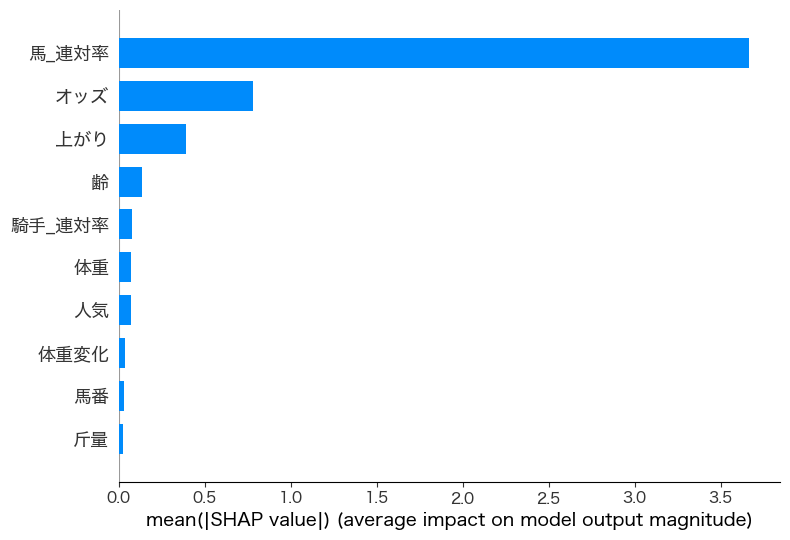

In [35]:
pred_proba = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test)

auc = roc_auc_score(y_test, pred_proba)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f'AUC: {auc:.3f}')
print(f'F1: {f1:.3f}')
print(f'Accuracy: {acc:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print('--- Confusion Matrix ---')
print(confusion_matrix(y_test, y_pred))
print('--- Classification Report ---')
print(classification_report(y_test, y_pred, digits=3))

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type='bar')

In [36]:
# しきい値を0.9にして評価
threshold = 0.9
y_pred_th07 = (pred_proba > threshold).astype(int)
print(f'--- threshold={threshold} ---')
print('Precision:', precision_score(y_test, y_pred_th07))
print('Recall:', recall_score(y_test, y_pred_th07))
print('F1:', f1_score(y_test, y_pred_th07))
print(confusion_matrix(y_test, y_pred_th07))

--- threshold=0.9 ---
Precision: 0.5393634840871022
Recall: 0.1494199535962877
F1: 0.23401162790697674
[[26106   275]
 [ 1833   322]]


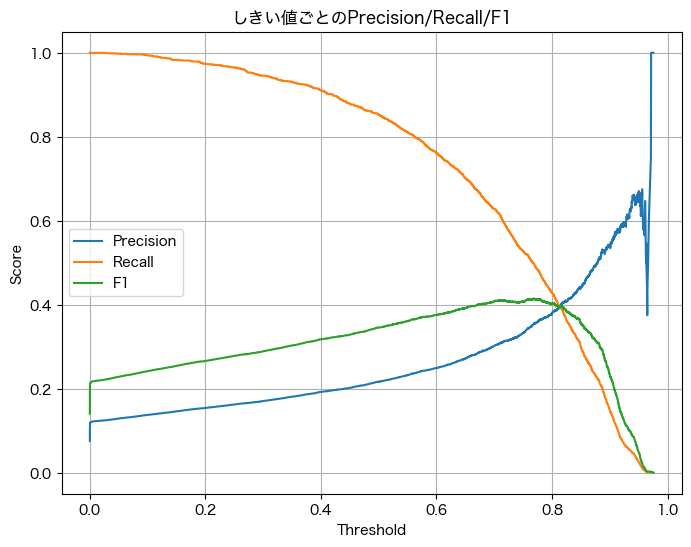

In [37]:
# しきい値ごとのprecision/recall/F1を可視化
from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba)
f1s = [f1_score(y_test, (pred_proba > t).astype(int)) for t in thresholds]

plt.figure(figsize=(8,6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1s, label='F1')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('しきい値ごとのPrecision/Recall/F1')
plt.legend()
plt.grid(True)
plt.show()